In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 데이터 불러오기

In [65]:
df = pd.read_csv('data/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# 다중회귀

## 변수 선택
* 3가지 독립변수 모두 선택

In [11]:
# -----------------------------------
# 독립변수, 종속변수 선택
# -----------------------------------
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

## 훈련세트 테스트세트 분할

In [66]:
# ------------------------------------------
# 훈련세트, 테스트세트 분할
# ------------------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test  = train_test_split(X, y, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(150, 3) (50, 3) (150,) (50,)


## 스케일링
- 선형회귀 모델은 변수의 스케일에 영향을 받음.
- 트리 모델은 스케일링의 영향을 거의 받지 않음.

In [112]:
# ------------------------------------------
# 독립변수 스케일링
# ------------------------------------------
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # 스케일러 생성(표준화)

# scaler.fit(X_train)  # scaler도 model처럼 학습시켜줘야 함 / 데이터 학습 및 스케일링 규칙 생성
# train_scaled = scaler.transform(X_train) # 데이터 변환
train_scaled = scaler.fit_transform(X_train)  # 훈련데이터는 fit_transform()
test_scaled = scaler.transform(X_test)  

In [113]:
# ------------------------------------------
# 독립변수 데이터프레임 형태로 변환
# ------------------------------------------
# 원래 모양인 넘파이 배열로 훈련하려고하면 모두 넘파이로 통일해줘야 함 
# 지금은 변수가 3개라 쉽지만 많아지면 컬럼이름이 안보이기 때문에 헷갈림 -> DF로 바꿔줘야함
X_train_scaled = pd.DataFrame(train_scaled, columns=X_train.columns) # 리스트 이름을 넣을 때 넘파이 배열 못넣음
X_test_scaled = pd.DataFrame(test_scaled, columns=X_test.columns)

In [114]:
# ------------------------------------------
# 스케일링 결과 확인
# ------------------------------------------
# 평균이 0, 표준편차가 1에 수렴하는 결과를 얻으면 성공
X_train_scaled.describe()

,TV,Radio,Newspaper
count,1.500000e+02,1.500000e+02,1.500000e+02
mean,-3.019807e-16,-2.368476e-17,4.263256e-16
std,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.795189e+00,-1.581617e+00,-1.459576e+00
25%,-7.853376e-01,-8.933672e-01,-8.618652e-01
50%,1.301900e-01,-1.007862e-01,-2.205965e-01
75%,7.942866e-01,9.374780e-01,7.304172e-01
max,1.691244e+00,1.756983e+00,3.409227e+00


## 모델 생성 및 훈련

In [115]:
# ------------------------------------------
# LinearRegression 클래스 import
# ------------------------------------------
from sklearn.linear_model import LinearRegression

# ------------------------------------------
# 모델객체 생성하기
# ------------------------------------------
model = LinearRegression()

# ------------------------------------------
# 훈련데이터로 모델 훈련하기
# ------------------------------------------
model.fit(X_train_scaled, y_train)

LinearRegression()

## 평가

In [116]:
from sklearn.metrics import mean_squared_error, \
                            mean_absolute_error, \
                            root_mean_squared_error, \
                            r2_score

# -----------------------------------
# 테스트데이터의 예측값
# -----------------------------------
y_pred = model.predict(X_test_scaled)

# -----------------------------------
# 모델 평가
# -----------------------------------
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('===다중회귀 모델의 평가결과===')
print(f'R2:{r2:.4f}')
print(f'RMSE:{rmse:.4f}')
print(f'MAE:{mae:.4f}')
print(f'MSE:{mse:.4f}')

===다중회귀 모델의 평가결과===
R2:0.9116
RMSE:1.5505
MAE:1.1200
MSE:2.4041


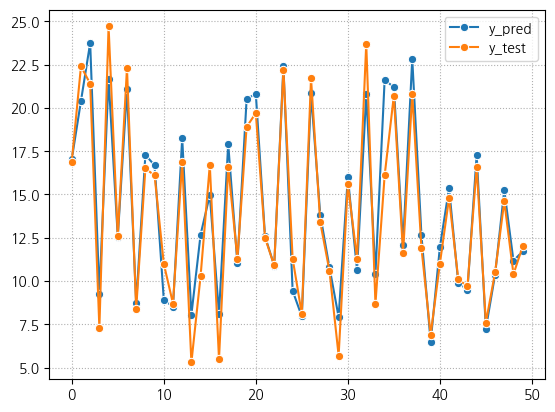

In [117]:
# ------------------------------------
# 실제값과 예측값 시각화 비교
# ------------------------------------
sns.lineplot(y_pred, marker='o', label='y_pred')
sns.lineplot(np.array(y_test), marker='o', label='y_test')
plt.grid(ls=':')
plt.legend()
pass

## 모델의 학습 결과

In [118]:
# ------------------------------------
# 회귀계수와 절편
# ------------------------------------
model.coef_, model.intercept_

# ------------------------------------
# 모델이 도출한 규칙
# ------------------------------------


(array([4.63204383, 1.48207916, 0.0889496 ]), 15.570666666666671)

<Axes: >

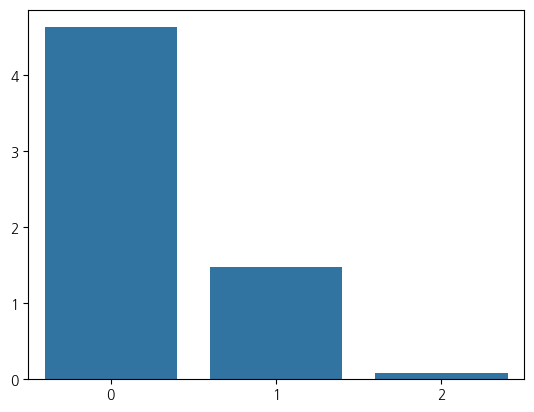

In [ ]:
# ------------------------------------
# 회귀계수 시각화
# ------------------------------------



## 새로운 값 예측하기
* 스케일링 된 데이터로 훈련했으므로 예측할 데이터도 스케일링을 해주어야 한다.
* 훈련세트에서 사용한 스케일려를 이용하여 스케일링한다.
* 이 때는 fit 하지 않고 transform만 한다.

In [120]:
# ---------------------------
# 새로운 값 입력받기
# ---------------------------
new_tv = int(input('tv 광고비 >>>'))
new_radio = int(input('radio 광고비 >>>'))
new_newspaper = int(input('newspaper 광고비 >>>'))

In [121]:
[[tv, radio, newspaper]]

[[100.0, 20.0, 30.0]]

In [122]:
# ---------------------------
# 새로운 값 스케일링
# ---------------------------
new_data = [[new_tv,new_radio,new_newspaper]]
new_data = pd.DataFrame(new_data, columns=X_test.columns)

new_data_scaled = scaler.transform(new_data)
new_data_scaled = pd.DataFrame(new_data_scaled, columns=X_test.columns)
new_data_scaled

,TV,Radio,Newspaper
0,-0.624398,-0.235407,-0.022166


In [125]:
# ---------------------------
# 새로운 값으로 예측
# ---------------------------
model.predict(new_data_scaled)

array([12.32756347])